In [2]:
import sys
sys.path.append('../')
import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
from brokenaxes import brokenaxes
import qutip as qt
import pandas as pd

### $\tilde{n}_{\theta 1}$ and $\tilde{n}_{\theta 2}$

In [3]:
truc_one_qubit, import_2000_states = 300, False 
[hspace_full, eket_tot, eval_tot, n_theta0_dress, 
    n_theta1_dress, hspace_0, hspace_1, logi_state
    ] = ut.load_qubit_data_2q(import_2000_states, truc_one_qubit)

In [4]:
ut.print_trans_freq('2-2','2-5', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-2','0-5', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('2-0','2-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-0','0-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)

ut.print_trans_freq('2-2','5-2', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('2-0','5-0', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-2','1-2', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-0','1-0', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)

ut.print_trans_freq('2-0','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-0','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)


ut.print_trans_freq('0-1','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('1-0','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('2-1','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('5-0','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
ut.print_trans_freq('2-2','2-5', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('0-2','0-5', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-0','2-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('0-0','0-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)

ut.print_trans_freq('2-2','5-2', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-0','5-0', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('0-2','1-2', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('0-0','1-0', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)

ut.print_trans_freq('2-0','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('0-0','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)


ut.print_trans_freq('0-1','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('1-0','1-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-1','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('5-0','5-1', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Charge matrix element

In [ ]:
def get_w_trans(truncation, evals, hspace_full, n_op, state_pop):
    thresh = 1e-1
    # hspace_idx = [hspace_full.index(i) for i in logi_state]
    # for s in hspace_idx:
    #     for i in range(truncation):
    #         if np.abs(n_op[s, i]/(2*np.pi)) > thresh and i not in hspace_idx:
    #             hspace_idx.append(i)
    # hspace_idx.sort()
    # hspace =

    # n_op = n_op[np.ix_(hspace_idx, hspace_idx)]
    w_trans = []
    trans_int = []
    n_trans = []
    for i, state_i in enumerate(hspace_full):
        if state_i in state_pop:
            for j, state_j in enumerate(hspace_full):
                if i < j and np.abs(n_op[i, j]/(2*np.pi)) > thresh:
                    w_trans.append(np.round( np.abs(evals[i] - evals[j]), 8))
                    trans_int.append((state_i, state_j))
                    n_trans.append( np.round( np.abs(n_op[i, j]/(2*np.pi)) , 3))
    sort_idx = np.argsort(w_trans)
    w_trans = np.sort(np.round(w_trans, 3))
    n_trans = [np.round(n_trans[i],3) for i in sort_idx]
    trans_int = [trans_int[i] for i in sort_idx]
    return w_trans, n_trans, trans_int

Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

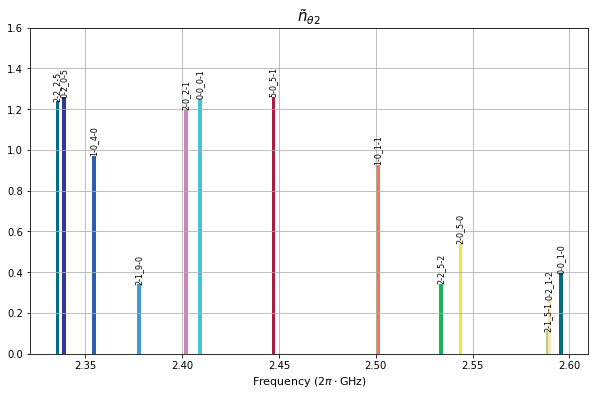

In [30]:
logi_state = ['0-0', '0-2', '2-0', '2-2', '1-0', '2-1', '5-0']
state_interest = logi_state
w_trans, n_trans, trans_int = get_w_trans(30, eval_tot, hspace_full, n_theta1_dress, state_interest)

width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
xlims = (2.3, 2.63)
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(w_trans)):
    if xlims[0] < w_trans[i]/(2*np.pi) < xlims[1]:
        txt_label = str(trans_int[i][0]) + '_' + str(trans_int[i][1])
        if trans_int[i] in [(0,7), (2,7)]:
            ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.1, color='red', alpha=0.5)
            ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center",
                        va="bottom", rotation=90, fontsize=30, fontweight='bold', color='red', alpha=0.5)
        else:
            ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.002, alpha=1)
            ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=8)
ax.set_ylim(0, 1.6)
ax.grid()
ax.set_title(r'$\tilde{n}_{\theta 2}$', fontsize=15)
ax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')

In [31]:
for i,j,k in zip(w_trans, n_trans, trans_int):
    if xlims[0] < i/(2*np.pi) < xlims[1]:
        print(f'{i},  {j},  {k}')

14.675,  1.239,  ('2-2', '2-5')
14.695,  1.258,  ('0-2', '0-5')
14.793,  0.972,  ('1-0', '4-0')
14.94,  0.342,  ('2-1', '9-0')
15.093,  1.196,  ('2-0', '2-1')
15.138,  1.252,  ('0-0', '0-1')
15.376,  1.26,  ('5-0', '5-1')
15.714,  0.928,  ('1-0', '1-1')
15.921,  0.344,  ('2-2', '5-2')
15.983,  0.541,  ('2-0', '5-0')
16.266,  0.11,  ('2-1', '5-1')
16.272,  0.268,  ('0-2', '1-2')
16.309,  0.394,  ('0-0', '1-0')


In [ ]:
print(n_trans)

[0.225, 0.307, 0.544, 1.69, 1.239, 1.258, 0.972, 0.342, 1.196, 1.252, 1.26, 0.928, 0.344, 0.541, 0.11, 0.268, 0.394, 0.116, 0.117]


In [16]:
w_trans

array([13.207, 13.49 , 14.05 , 14.38 , 14.675, 14.695, 14.793, 14.94 ,
       15.093, 15.138, 15.376, 15.714, 15.921, 15.983, 16.266, 16.272,
       16.309, 21.257, 21.27 ])

In [18]:
trans_int

[('1-0', '0-4'),
 ('5-0', '2-4'),
 ('5-0', '9-0'),
 ('2-1', '2-4'),
 ('2-2', '2-5'),
 ('0-2', '0-5'),
 ('1-0', '4-0'),
 ('2-1', '9-0'),
 ('2-0', '2-1'),
 ('0-0', '0-1'),
 ('5-0', '5-1'),
 ('1-0', '1-1'),
 ('2-2', '5-2'),
 ('2-0', '5-0'),
 ('2-1', '5-1'),
 ('0-2', '1-2'),
 ('0-0', '1-0'),
 ('2-2', '2-8'),
 ('0-2', '0-8')]

Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

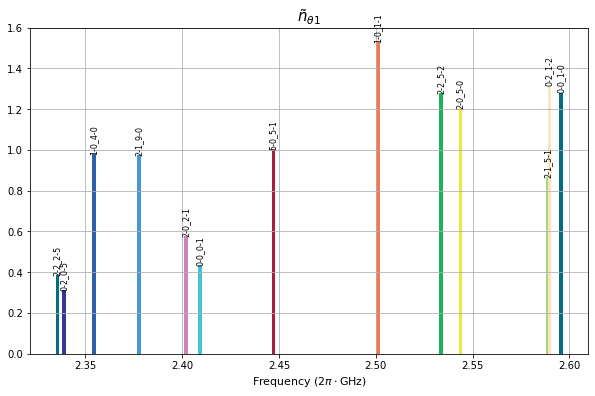

In [19]:
logi_state = ['0-0', '0-2', '2-0', '2-2', '1-0', '2-1', '5-0']
state_interest = logi_state
w_trans, n_trans, trans_int = get_w_trans(30, eval_tot, hspace_full, n_theta0_dress, state_interest)

width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
xlims = (2.3, 2.63)
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(w_trans)):
    if xlims[0] < w_trans[i]/(2*np.pi) < xlims[1]:
        txt_label = str(trans_int[i][0]) + '_' + str(trans_int[i][1])
        if trans_int[i] in [(0,7), (2,7)]:
            ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.1, color='red', alpha=0.5)
            ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center",
                        va="bottom", rotation=90, fontsize=30, fontweight='bold', color='red', alpha=0.5)
        else:
            ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.002, alpha=1)
            ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=8)
ax.set_ylim(0, 1.6)
ax.grid()
ax.set_title(r'$\tilde{n}_{\theta 1}$', fontsize=15)
ax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')

In [24]:
np.array([2.3, 2.63])* 2*np.pi

array([14.45132621, 16.52477736])

In [ ]:
for i,j,k in zip(w_trans, n_trans, trans_int):
    if xlims[0] < i/(2*np.pi) < xlims[1]:
        print(f'{i},  {j},  {k}')

14.675,  0.386,  ('2-2', '2-5')
14.695,  0.312,  ('0-2', '0-5')
14.793,  0.978,  ('1-0', '4-0')
14.94,  0.973,  ('2-1', '9-0')
15.093,  0.577,  ('2-0', '2-1')
15.138,  0.434,  ('0-0', '0-1')
15.376,  1.003,  ('5-0', '5-1')
15.714,  1.528,  ('1-0', '1-1')
15.921,  1.278,  ('2-2', '5-2')
15.983,  1.204,  ('2-0', '5-0')
16.266,  0.866,  ('2-1', '5-1')
16.272,  1.316,  ('0-2', '1-2')
16.309,  1.281,  ('0-0', '1-0')


In [20]:
print(n_trans)

[0.146, 1.297, 0.572, 0.386, 0.312, 0.978, 0.973, 0.577, 0.434, 1.003, 1.528, 1.278, 1.204, 0.866, 1.316, 1.281, 0.198, 0.441, 0.162, 0.215, 0.132]


In [21]:
w_trans

array([13.49 , 14.05 , 14.38 , 14.675, 14.695, 14.793, 14.94 , 15.093,
       15.138, 15.376, 15.714, 15.921, 15.983, 16.266, 16.272, 16.309,
       21.14 , 21.327, 22.217, 24.597, 38.687])

In [22]:
trans_int

[('5-0', '2-4'),
 ('5-0', '9-0'),
 ('2-1', '2-4'),
 ('2-2', '2-5'),
 ('0-2', '0-5'),
 ('1-0', '4-0'),
 ('2-1', '9-0'),
 ('2-0', '2-1'),
 ('0-0', '0-1'),
 ('5-0', '5-1'),
 ('1-0', '1-1'),
 ('2-2', '5-2'),
 ('2-0', '5-0'),
 ('2-1', '5-1'),
 ('0-2', '1-2'),
 ('0-0', '1-0'),
 ('5-0', '1-8'),
 ('5-0', '12-0'),
 ('2-1', '12-0'),
 ('5-0', '13-0'),
 ('5-0', '22-0')]

In [ ]:
=

### Compare hspace_0 and hspace_1

In [ ]:
truc1, truc_tot, charge_pick = 300, 1000, True
folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
hspace_true = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
hspace_0 = pd.read_csv(folder+ 'hspace_0.txt').to_numpy().flatten().tolist()
hspace_1 = pd.read_csv(folder+ 'hspace_1.txt').to_numpy().flatten().tolist()
print('hspace_0=', hspace_0)
print('hspace_1=', hspace_1)

hspace_0= [0, 1, 2, 4, 5, 8, 9, 12, 13, 15, 18, 20, 22, 24, 25, 26, 28, 30, 33, 34, 35, 37, 39, 41, 44, 45, 46, 50, 51, 54, 56, 58, 59, 60, 64, 65, 66, 69, 70, 74, 75, 77, 79, 81, 84, 85, 86, 89, 90, 92, 93, 98, 99, 100, 101, 102, 105, 106, 109, 110, 111, 115, 116, 121, 123, 124, 127, 128, 129, 131, 132, 135, 136, 138, 140, 141, 144, 145, 147, 150, 151, 154, 157, 160, 161, 162, 165, 167, 169, 170, 173, 174, 175, 177, 179, 180, 183, 185, 188, 189, 194, 195, 198, 199, 200, 201, 204, 205, 207, 208, 210, 213, 214, 216, 218, 222, 223, 224, 225, 228, 229, 234, 235, 238, 241, 244, 247, 248, 249, 250, 251, 252, 254, 255, 260, 261, 262, 263, 264, 265, 269, 270, 271, 275, 277, 281, 282, 286, 288, 289, 293, 294, 295, 299]
hspace_1= [0, 1, 2, 4, 5, 8, 9, 12, 13, 16, 18, 20, 21, 24, 25, 26, 28, 30, 33, 34, 35, 36, 39, 42, 44, 45, 46, 52, 53, 54, 55, 57, 59, 60, 64, 65, 66, 68, 70, 73, 76, 77, 78, 81, 82, 83, 86, 89, 90, 92, 93, 97, 98, 100, 102, 103, 105, 106, 109, 110, 112, 114, 116, 121, 123, 124

In [ ]:
ut.compare_two_lists(hspace_0, hspace_1)

list1 and list2 have 114 common elements and 40 unique elements.

Only in list1 (len=40) = np.array([

15, 22, 37, 41, 50, 51, 56, 58, 69, 74 ,
75, 79, 84, 85, 99, 101, 111, 115, 127, 151 ,
154, 157, 167, 173, 177, 183, 185, 188, 189, 198 ,
199, 200, 201, 208, 218, 234, 277, 281, 282, 286 ,
])

index Only in list1 (len=40) = np.array([

9, 12, 21, 23, 27, 28, 30, 31, 37, 39 ,
40, 42, 44, 45, 52, 54, 60, 61, 66, 80 ,
81, 82, 87, 90, 93, 96, 97, 98, 99, 102 ,
103, 104, 105, 109, 114, 121, 144, 145, 146, 147 ,
])

Only in list2 (len=41) = np.array([

16, 21, 36, 42, 52, 53, 55, 57, 68, 73 ,
76, 78, 82, 83, 97, 103, 112, 114, 125, 152 ,
153, 155, 168, 171, 178, 182, 184, 192, 193, 196 ,
197, 202, 203, 206, 217, 232, 276, 283, 284, 285 ,
298 ,
])

index Only in list2 (len=41) = np.array([

9, 12, 21, 23, 27, 28, 30, 31, 37, 39 ,
40, 42, 44, 45, 51, 55, 60, 61, 66, 80 ,
81, 82, 87, 90, 93, 96, 97, 98, 99, 102 ,
103, 104, 105, 108, 114, 121, 144, 145, 146, 147 ,
153 ,
])


### ${n}_{\theta 1}$ and ${n}_{\theta 2}$ in coupled system

### Import check

In [ ]:
truc_import = 500
folder = f'../../data/3ncut_two_zeropi/truc1={truc_import}/'
n_theta0 = np.load(folder+'n_theta0.npy')
n_theta1 = np.load(folder+'n_theta1.npy')

In [ ]:
vmax = 0.1
truc2 = 10
fig, ax = plt.subplots(figsize=(6,5))
font_size = 15
plt.imshow(np.abs(n_theta0[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'Coupled $n_{\theta 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

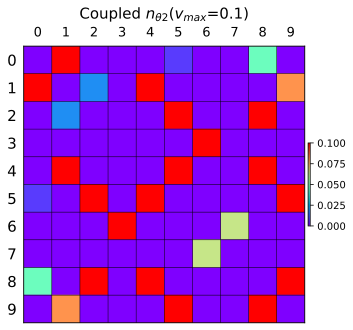

In [ ]:
vmax = 0.1
truc2 = 10
fig, ax = plt.subplots(figsize=(6,5))
font_size = 15
plt.imshow(np.abs(n_theta1[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'Coupled $n_{\theta 2}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

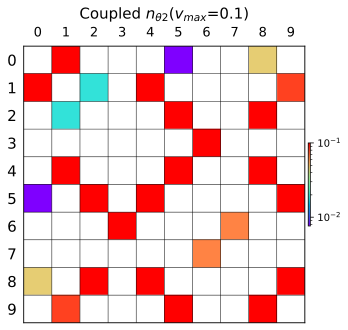

In [ ]:
# logarithmic scale
from matplotlib.colors import LogNorm
vmax = 0.1
truc2 = 10
fig, ax = plt.subplots(figsize=(6,5))
font_size = 15
plt.imshow(np.abs(n_theta1[:truc2,:truc2]), aspect="auto", norm=LogNorm(vmax=vmax), cmap='rainbow')
plt.title(r'Coupled $n_{\theta 2}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=13)
ax.set_yticks(np.arange(0, truc2), np.arange(0, truc2), fontsize=15)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [ ]:
qt.Qobj(np.abs(n_theta1[:truc2,:truc2])[[2,0]])

Quantum object: dims = [[2], [10]], shape = (2, 10), type = oper, isherm = False
Qobj data =
[[0.         0.01883263 0.         0.         0.         1.28549462
  0.         0.         0.11683501 0.        ]
 [0.         1.31207974 0.         0.         0.         0.00762752
  0.         0.         0.04614325 0.        ]]

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
n_theta0

array([[ 0.00000000e+00+0.j, -1.35218494e+00+0.j,  0.00000000e+00+0.j,
        ..., -8.10000000e-07+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [-1.35218494e+00+0.j,  0.00000000e+00+0.j, -1.03945100e-02+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j, -1.03945100e-02+0.j,  0.00000000e+00+0.j,
        ...,  4.20000000e-07+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       ...,
       [-8.10000000e-07+0.j,  0.00000000e+00+0.j,  4.20000000e-07+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         5.83025008e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  5.83025008e+00+0.j,
         0.00000000e+00+0.j]])

In [ ]:
len(trans_int)
# [print(i) if 47 in i else None for i in trans_int]
for i in trans_int:
    if 47 in i:
        # print(i)
        ut.print_trans_freq(i[0], i[1], eval0, n_Phi=n_phi0)

In [ ]:
# state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_phi = [0, 2, 3, 4, 8, 9, 10, 11, 15, 16 ,
18, 19, 20, 24, 25, 28, 31, 33, 35 ]
w_trans, n_trans, trans_int = get_w_trans(truc1, eval0, n_phi0, state_phi)
width = 0.8
y_shift = 0.0
state_overlap = ['47-91', '9-31']
x_shift = [-0.3,-0.3]
# xlims = ((0.5, 1.5), (2, 3)) # 1 state
xlims = ((3.1, 6.5), (7., 9.6)) # 7 state
# xlims = ((27.3, 30.8), (49.1, 53.9))
fig = plt.figure(figsize=(15, 8))
ax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            txt_label = str(trans_int[i][0]) + '-' + str(trans_int[i][1])
            if trans_int[i] in [(0,9), (2,9)]:
                ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.2, color='red', alpha=0.5)
                ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center",
                         va="bottom", rotation=90, fontsize=30, fontweight='bold', color='red', alpha=0.5)
            else:
                ax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.005, alpha=0.5)
                ax.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
# bax.set_ylim(0, 0.4)
ax.grid()
ax.set_title(r'$n_\phi$', fontsize=15)
# bax.set_title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)
ax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')
# plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

#### Matrix element table

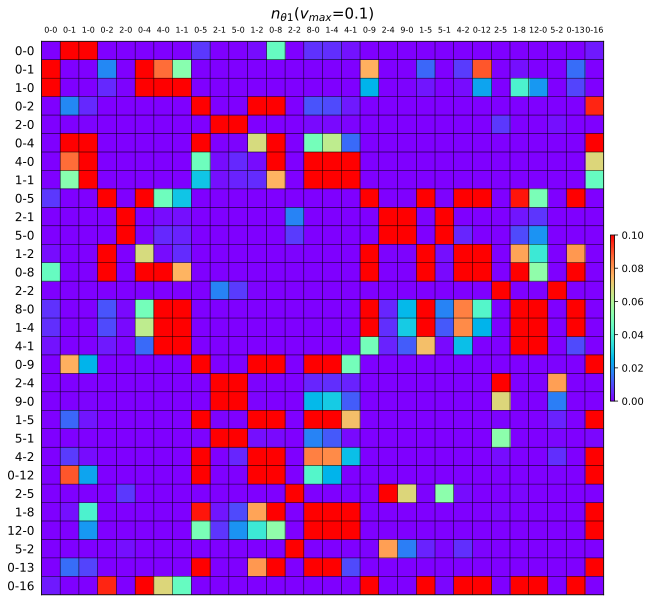

In [ ]:
vmax = 0.1
truc2 = 30
fig, ax = plt.subplots(figsize=(12,10))
font_size = 15
hspace_label = hspace_full[:truc2]
plt.imshow(np.abs(n_theta1_dress[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), hspace_label, fontsize=8)
ax.set_yticks(np.arange(0, truc2), hspace_label, fontsize=12)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

Text(0.5, 1.0, '$n_\\theta$')

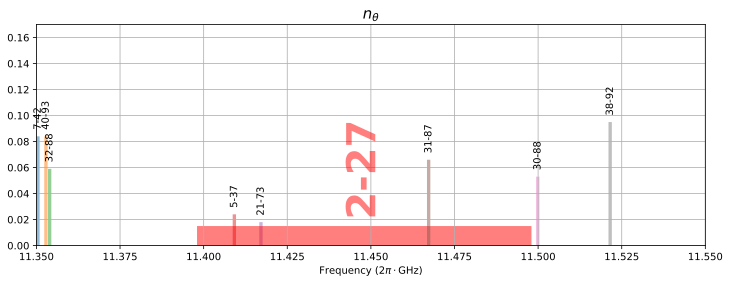

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
y_shift = 0.005
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max =11.35, 11.55
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i]/(2*np.pi) < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['0-27', '2-27']:
            plt.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.1, color='red', alpha=0.5)
            plt.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, trans[i],
                     ha="center", va="bottom", rotation=90, fontsize=40, fontweight='bold', color='red', alpha=0.5)
        # elif trans[i] in state_overlap:
        #     plt.bar(w_trans[i], trans_mat[i], width=0.02)
            # plt.text(w_trans[i]-0.3, trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=5)
        else:
            plt.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.001, alpha=0.5)
            plt.text(w_trans[i]/(2*np.pi), n_trans[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=10)

plt.ylim(0,0.17)
plt.xlim(x_min,x_max)
plt.xlabel(r'Frequency (2$\pi\cdot$GHz)')
plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
ax.set_title(r'$n_\theta$', fontsize=15)
# plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)